In [1]:
!pip install pandas
!pip install matplotlib
!pip install nltk
!pip install NRCLex==3.0.0
!pip install textblob
!pip install vaderSentiment

### Part A: Corpus Construction

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("goemotions_raw_train_simplified.csv")

In [4]:
data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1548381000,1
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1548084200,37
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1546427800,37
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1547965000,18
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1546668500,2


In [5]:
data.describe()

,created_utc,rater_id
count,2.112250e+05,211225.000000
mean,1.547659e+09,37.619742
std,7.696842e+05,23.070528
min,1.546301e+09,0.000000
25%,1.546993e+09,19.000000
50%,1.547664e+09,37.000000
75%,1.548320e+09,57.000000
max,1.548979e+09,81.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         211225 non-null  object
 1   id           211225 non-null  object
 2   author       211225 non-null  object
 3   subreddit    211225 non-null  object
 4   link_id      211225 non-null  object
 5   parent_id    211225 non-null  object
 6   created_utc  211225 non-null  int64 
 7   rater_id     211225 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 12.9+ MB


In [7]:
data.drop_duplicates(subset="id", inplace=True)

In [8]:
corpus_data = data[data["subreddit"].str.contains("gunpolitics|progun|liberalgunowners")]
corpus_data

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16
...,...,...,...,...,...,...,...,...
159343,Used to be just bad on the 2nd. Now they are f...,edzjono,GOA_AMD65,progun,t3_afk8sa,t1_edzb9is,1547400800,34
161004,When you glossed over [NAME] history to make a...,efao1b1,RowdyPants,gunpolitics,t3_akzvn0,t1_efam9kw,1548795600,61
168438,I think theres a line between edgy and racist ...,edou5u6,d48reu,liberalgunowners,t3_aecsno,t1_edou1nn,1547095200,18
174902,And I wish I wasn't lumped in with new jersey.,eet08tq,velocibadgery,gunpolitics,t3_aj2a74,t1_eeszyht,1548287700,23


In [9]:
corpus_data[corpus_data["subreddit"] == "gunpolitics"].info()
corpus_data[corpus_data["subreddit"] == "gunpolitics"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 68 entries, 215 to 174902
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         68 non-null     object
 1   id           68 non-null     object
 2   author       68 non-null     object
 3   subreddit    68 non-null     object
 4   link_id      68 non-null     object
 5   parent_id    68 non-null     object
 6   created_utc  68 non-null     int64 
 7   rater_id     68 non-null     int64 
dtypes: int64(2), object(6)
memory usage: 4.8+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26
1197,SAF is also in the list for Facebook. I trigge...,ed9kwvh,shikkie,gunpolitics,t3_acnfv1,t1_ed9jg2i,1546648700,5
1364,"I think it’s a bit more complicated than that,...",ef6xwp8,Slowroll900,gunpolitics,t3_akp27t,t1_ef6xbtl,1548700400,39
3156,See my post about Ohio above. Not as bad as yo...,eetcctg,jimhjim,gunpolitics,t3_aj2a74,t1_eescljs,1548297000,61
3784,"I wish, the brainwashed idiots here in Califor...",efd8e5q,TPBfan74,gunpolitics,t3_al9h43,t1_efbzpwy,1548864100,19


In [10]:
corpus_data[corpus_data["subreddit"] == "progun"].info()
corpus_data[corpus_data["subreddit"] == "progun"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 146 to 185689
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         128 non-null    object
 1   id           128 non-null    object
 2   author       128 non-null    object
 3   subreddit    128 non-null    object
 4   link_id      128 non-null    object
 5   parent_id    128 non-null    object
 6   created_utc  128 non-null    int64 
 7   rater_id     128 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 9.0+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16
968,And in some aren't permitted outside the home ...,eenlie8,DammitDan,progun,t3_ai593r,t1_eelftvl,1548115700,6
1081,How so. What is the basis for your feeling of ...,eeugdp1,justbingitxxx,progun,t3_aj7nto,t1_eeufqlx,1548340900,18


In [11]:
corpus_data[corpus_data["subreddit"] == "liberalgunowners"].info()
corpus_data[corpus_data["subreddit"] == "liberalgunowners"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 222 to 168438
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         156 non-null    object
 1   id           156 non-null    object
 2   author       156 non-null    object
 3   subreddit    156 non-null    object
 4   link_id      156 non-null    object
 5   parent_id    156 non-null    object
 6   created_utc  156 non-null    int64 
 7   rater_id     156 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 11.0+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50
1339,There is clearly something really goddamned wr...,edekjf0,DMooseJ,liberalgunowners,t3_ad5toc,t1_edegg8e,1546800900,22
1481,"I loathe him too, but I couldn't even get on b...",ednmhrc,bagofwisdom,liberalgunowners,t3_ae9x2m,t1_ednmcdm,1547062300,50
1625,"But the poster, on the other hand...",ed5ljmp,jajajajaj,liberalgunowners,t3_ac2kqm,t1_ed5hjp1,1546529800,70
1913,Not bad at all.,edvct1g,2ChanceRescue,liberalgunowners,t3_actskz,t1_edd0re9,1547271000,36


### Part B: VADER Sentiment Analysis

In [12]:
corpus_data.insert(8, "vader_positive", 0.0)
corpus_data.insert(9, "vader_negative", 0.0)
corpus_data.insert(10, "vader_neutral", 0.0)
corpus_data.insert(11, "vader_compound", 0.0)
corpus_data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,vader_positive,vader_negative,vader_neutral,vader_compound
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6,0.0,0.0,0.0,0.0
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26,0.0,0.0,0.0,0.0
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50,0.0,0.0,0.0,0.0
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12,0.0,0.0,0.0,0.0
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16,0.0,0.0,0.0,0.0


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
for index, row in corpus_data.iterrows():
    vs = analyzer.polarity_scores(row["text"])
    corpus_data.loc[index, ["vader_positive"]] = vs["pos"]
    corpus_data.loc[index, ["vader_negative"]] = vs["neg"]
    corpus_data.loc[index, ["vader_neutral"]] = vs["neu"]
    corpus_data.loc[index, ["vader_compound"]] = vs["compound"]

In [14]:
corpus_data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,vader_positive,vader_negative,vader_neutral,vader_compound
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6,0.219,0.000,0.781,0.4215
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26,0.000,0.063,0.937,-0.0900
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50,0.151,0.146,0.703,0.0258
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12,0.478,0.373,0.149,0.1779
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16,0.166,0.083,0.751,0.4749


In [15]:
import matplotlib.pyplot as plt

<Axes: >

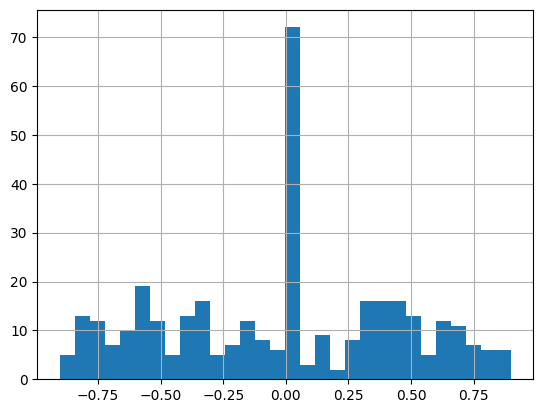

In [16]:
corpus_data["vader_compound"].hist(bins=30)

In [17]:
# plt.hist(corpus_data["vader_compound"], bins=30, edgecolor='black')
# corpus_data["vader_compound"].plot(kind='hist', bins=30, edgecolor='black')

### Part C: NRC Emotion Lexicon Analysis

In [18]:
import re

def change(data):
    for index, row in data.iterrows():
        data.loc[index, ["text"]] = re.sub(r'[^\w\s]', '', row["text"].lower())
    return data

cleaned_corpus_data = corpus_data.copy().drop(columns=["vader_positive", "vader_negative", "vader_neutral", "vader_compound"])
cleaned_corpus_data = change(cleaned_corpus_data)

In [19]:
cleaned_corpus_data.tail()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
159343,used to be just bad on the 2nd now they are fo...,edzjono,GOA_AMD65,progun,t3_afk8sa,t1_edzb9is,1547400800,34
161004,when you glossed over name history to make a c...,efao1b1,RowdyPants,gunpolitics,t3_akzvn0,t1_efam9kw,1548795600,61
168438,i think theres a line between edgy and racist ...,edou5u6,d48reu,liberalgunowners,t3_aecsno,t1_edou1nn,1547095200,18
174902,and i wish i wasnt lumped in with new jersey,eet08tq,velocibadgery,gunpolitics,t3_aj2a74,t1_eeszyht,1548287700,23
185689,yes im an idiot checks out,efb0gx3,Randaethyr,progun,t3_al1uth,t1_efashlb,1548803000,57


Using NRCLex to get the scores.

In [20]:
# Run once if TextBlob/NRClex corpora are missing:
# import nltk
# nltk.download("punkt")
# nltk.download("wordnet")
# nltk.download("averaged_perceptron_tagger")
# nltk.download("brown")

In [21]:
from nrclex import NRCLex

str_corpus = ' '.join(cleaned_corpus_data["text"])
text_object = NRCLex(str_corpus)

In [22]:
corpus_emotions = text_object.raw_emotion_scores
corpus_emotions

{'positive': 213,
 'disgust': 93,
 'negative': 274,
 'anger': 167,
 'fear': 174,
 'surprise': 56,
 'sadness': 121,
 'trust': 133,
 'anticipation': 101,
 'joy': 85}

In [23]:
str_subreddit1 = ' '.join(cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "gunpolitics"]["text"])
text_object = NRCLex(str_subreddit1)
subreddit1_emotions = text_object.raw_emotion_scores
subreddit1_emotions

{'disgust': 21,
 'negative': 54,
 'positive': 39,
 'anger': 31,
 'fear': 28,
 'surprise': 9,
 'anticipation': 15,
 'joy': 18,
 'sadness': 23,
 'trust': 18}

In [24]:
str_subreddit2 = ' '.join(cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "progun"]["text"])
text_object = NRCLex(str_subreddit2)
subreddit2_emotions = text_object.raw_emotion_scores
subreddit2_emotions

{'positive': 90,
 'negative': 97,
 'trust': 68,
 'anger': 68,
 'fear': 77,
 'anticipation': 49,
 'disgust': 31,
 'joy': 38,
 'sadness': 51,
 'surprise': 29}

In [25]:
str_subreddit3 = ' '.join(cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "liberalgunowners"]["text"])
text_object = NRCLex(str_subreddit3)
subreddit3_emotions = text_object.raw_emotion_scores
subreddit3_emotions

{'fear': 69,
 'negative': 123,
 'sadness': 47,
 'positive': 84,
 'trust': 47,
 'anger': 68,
 'disgust': 41,
 'anticipation': 37,
 'surprise': 18,
 'joy': 29}

In [26]:
# from limbic.emotion.models import LexiconLimbicEsModel
# from limbic.emotion.nrc_utils import load_nrc_lexicon

# nrc_lexcon_file_path = '../lab1_resources/nltk_data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'
# lexicon = load_nrc_lexicon(nrc_lexicon_file_path, 'affect_intensity')
# lb = LexiconLimbicEsModel(lexicon)
# print(lb.get_sentence_emotions(str_subreddit1))

Using lexicon from the resourses provided.

In [27]:
from pathlib import Path

def load_nrc_lexicon(path):
    lexicon_df = pd.read_csv(path, sep='\t', header=None, names=["word", "emotion", "value"], keep_default_na=False)
    return lexicon_df

file_path = Path("lab1_dictionary_sentiment.ipynb").resolve().parent
lexicon_df = load_nrc_lexicon(file_path / 'lab1_resources/nltk_data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt')
lexicon_df.head()

,word,emotion,value
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0


In [28]:
pivoted = lexicon_df.pivot(index="word", columns="emotion", values="value")
# pivoted = pivoted.iloc[1:]
pivoted.head()

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
word,,,,,,,,,,
aback,0,0,0,0,0,0,0,0,0,0
abacus,0,0,0,0,0,0,0,0,0,1
abandon,0,0,0,1,0,1,0,1,0,0
abandoned,1,0,0,1,0,1,0,1,0,0
abandonment,1,0,0,1,0,1,0,1,1,0


In [29]:
matrix = cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "gunpolitics"]["text"].str.split()
str_lexicon_subreddit1 = [item for row in matrix for item in row]

In [30]:
matched_words1 = [word for word in str_lexicon_subreddit1 if word in pivoted.index]
subreddit1_lexicon_emotions = pivoted.loc[matched_words1].sum()
subreddit1_lexicon_emotions

emotion
anger           31
anticipation    15
disgust         21
fear            28
joy             18
negative        54
positive        39
sadness         23
surprise         9
trust           18
dtype: int64

In [31]:
matrix = cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "progun"]["text"].str.split()
str_lexicon_subreddit2 = [item for row in matrix for item in row]
matched_words2 = [word for word in str_lexicon_subreddit2 if word in pivoted.index]
subreddit2_lexicon_emotions = pivoted.loc[matched_words2].sum()

matrix = cleaned_corpus_data[cleaned_corpus_data["subreddit"] == "liberalgunowners"]["text"].str.split()
str_lexicon_subreddit3 = [item for row in matrix for item in row]
matched_words3 = [word for word in str_lexicon_subreddit3 if word in pivoted.index]
subreddit3_lexicon_emotions = pivoted.loc[matched_words3].sum()

### Part D: Visualization
A histogram of VADER compound sentiment scores can be found above.

<BarContainer object of 10 artists>

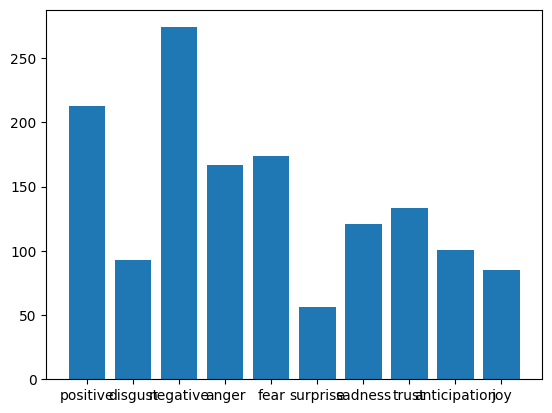

In [32]:
plt.bar(corpus_emotions.keys(), corpus_emotions.values())

In [33]:
import matplotlib.pyplot as plt

bar_data = pd.DataFrame([subreddit1_emotions])
bar_data.loc[1] = subreddit2_emotions.values()
bar_data.loc[2] = subreddit3_emotions.values()
bar_data.insert(0, "index", ["gunpolitics", "progun", "liberalgunowners"])

In [34]:
bar_data.sort_index(axis=1, inplace=True)
bar_data

,anger,anticipation,disgust,fear,index,joy,negative,positive,sadness,surprise,trust
0,31,15,21,28,gunpolitics,18,54,39,23,9,18
1,68,31,90,77,progun,38,97,68,51,49,29
2,84,41,69,47,liberalgunowners,37,123,47,18,68,29


<Axes: title={'center': 'Grouped Bar Graph with dataframe'}, xlabel='index'>

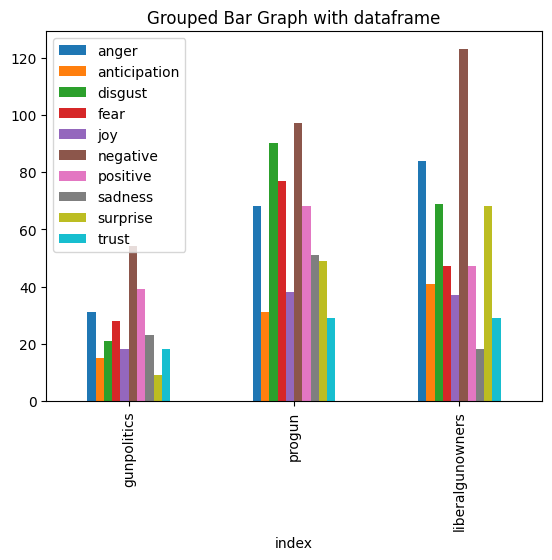

In [35]:
# plot grouped bar chart
bar_data.plot(x="index",
        kind='bar',
        stacked=False,
        title='Grouped Bar Graph with dataframe')

In [36]:
emotions = list(bar_data.columns)[1:]
emotions

['anticipation',
 'disgust',
 'fear',
 'index',
 'joy',
 'negative',
 'positive',
 'sadness',
 'surprise',
 'trust']

In [37]:
import matplotlib.pyplot as plt

# Combine into a DataFrame
df = pd.DataFrame({"gunpolitics": subreddit1_lexicon_emotions, 
                   "progun": subreddit2_lexicon_emotions, "liberalgunowners": subreddit3_lexicon_emotions})

# bar_data = pd.DataFrame([subreddit1_lexicon_emotions])
# bar_data.loc[1] = subreddit2_lexicon_emotions
# bar_data.loc[2] = subreddit3_lexicon_emotions
# bar_data.insert(0, "index", ["gunpolitics", "progun", "liberalgunowners"])

In [38]:
df = df.transpose()
df

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
gunpolitics,31,15,21,28,18,54,39,23,9,18
progun,68,49,31,76,38,96,90,50,29,68
liberalgunowners,68,37,41,69,29,123,84,47,18,47


<Axes: title={'center': 'Grouped Bar Graph with dataframe'}>

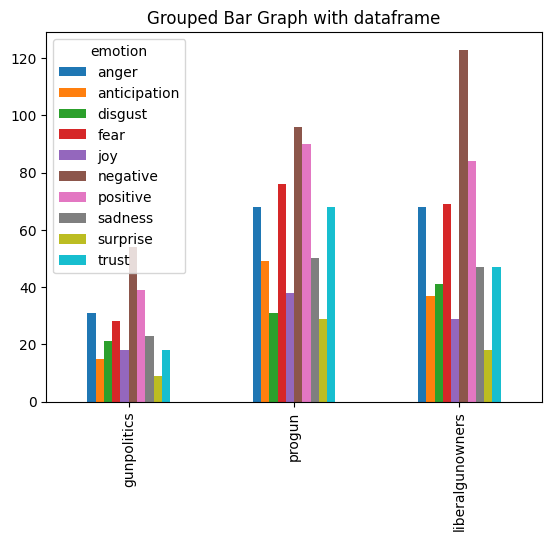

In [39]:
df.plot(kind='bar',
        stacked=False,
        title='Grouped Bar Graph with dataframe')